# Plot nanoGPT profiler data

Run the cells below to load `profiler/nanogpt.csv` and render the interactive matplotlib view inside Jupyter.

In [1]:
import csv
from collections import Counter
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PHASE_COLORS = {
    "forward": "#2E86AB",
    "backward": "#D95D39",
    "optimizer": "#2A9D8F",
    "checkpoint": "#6A4C93",
    "dataloader": "#E9C46A",
    "idle": "#BFC0C0",
}

def resolve_csv_path() -> Path:
    candidates = [
        Path.cwd() / "profiler" / "nanogpt.csv",
        Path.cwd().parent / "profiler" / "nanogpt.csv",
        Path("../profiler/nanogpt.csv"),
        Path("profiler/nanogpt.csv"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find profiler/nanogpt.csv from the current notebook working directory")

def parse_float(value: str):
    if value == "":
        return None
    return float(value)

def load_rows(csv_path: Path) -> list[dict]:
    with csv_path.open() as handle:
        raw_rows = list(csv.DictReader(handle))
    if not raw_rows:
        raise ValueError(f"no rows found in {csv_path}")

    timestamps = [datetime.fromisoformat(row["timestamp"]) for row in raw_rows]
    t0 = timestamps[0]
    rows = []
    for raw, ts in zip(raw_rows, timestamps):
        rows.append(
            {
                "elapsed_s": (ts - t0).total_seconds(),
                "step": int(raw["step"]),
                "phase": raw["phase"],
                "cpu": parse_float(raw["cpu_util_percent"]),
                "gpu": parse_float(raw["gpu_util_percent"]),
                "gpu_mem": parse_float(raw["gpu_mem_mb"]),
                "host_mem": parse_float(raw["host_mem_mb"]),
                "disk_read": parse_float(raw["disk_read_mb_s"]),
                "disk_write": parse_float(raw["disk_write_mb_s"]),
            }
        )
    return rows

def series(rows: list[dict], key: str) -> list[float]:
    return [float("nan") if row[key] is None else row[key] for row in rows]


In [2]:
def plot_summary(ax, rows: list[dict], csv_path: Path) -> None:
    ax.axis("off")
    duration = rows[-1]["elapsed_s"]
    valid_steps = [row["step"] for row in rows if row["step"] >= 0]
    step_text = f"{min(valid_steps)}..{max(valid_steps)}" if valid_steps else "n/a"
    peak_gpu_mem = max((row["gpu_mem"] or 0.0) for row in rows)
    peak_host_mem = max((row["host_mem"] or 0.0) for row in rows)
    peak_disk_write = max((row["disk_write"] or 0.0) for row in rows)
    counts = Counter(row["phase"] for row in rows)
    dominant_phase = counts.most_common(1)[0][0]

    ax.text(0.01, 0.92, "nanoGPT Training Profile", fontsize=20, fontweight="bold", transform=ax.transAxes)
    ax.text(0.01, 0.77, str(csv_path), fontsize=10, color="#666666", transform=ax.transAxes)

    cards = [
        ("Samples", str(len(rows))),
        ("Duration", f"{duration:.1f}s"),
        ("Steps", step_text),
        ("Dominant Phase", dominant_phase),
        ("Peak GPU Mem", f"{peak_gpu_mem:.0f} MB"),
        ("Peak Host Mem", f"{peak_host_mem:.0f} MB"),
        ("Peak Disk Write", f"{peak_disk_write:.1f} MB/s"),
    ]

    x_positions = [0.01, 0.26, 0.51, 0.76]
    y_positions = [0.52, 0.20]
    idx = 0
    for y in y_positions:
        for x in x_positions:
            if idx >= len(cards):
                break
            label, value = cards[idx]
            ax.text(x, y, label, fontsize=10, color="#666666", transform=ax.transAxes)
            ax.text(x, y - 0.15, value, fontsize=14, fontweight="bold", transform=ax.transAxes)
            idx += 1

def plot_phase_timeline(ax, rows: list[dict]) -> None:
    duration = max(rows[-1]["elapsed_s"], 1e-9)
    start_idx = 0
    for idx in range(1, len(rows) + 1):
        boundary = idx == len(rows) or rows[idx]["phase"] != rows[start_idx]["phase"]
        if not boundary:
            continue
        start_t = rows[start_idx]["elapsed_s"]
        end_t = rows[idx]["elapsed_s"] if idx < len(rows) else duration
        color = PHASE_COLORS.get(rows[start_idx]["phase"], "#999999")
        ax.axvspan(start_t, end_t, ymin=0.25, ymax=0.75, color=color, ec="none")
        start_idx = idx

    handles = [Patch(facecolor=PHASE_COLORS[name], label=name) for name in PHASE_COLORS]
    ax.legend(handles=handles, loc="upper center", ncol=6, frameon=False, bbox_to_anchor=(0.5, 1.25))
    ax.set_title("Phase Timeline")
    ax.set_xlim(0, duration)
    ax.set_yticks([])
    ax.set_xlabel("Elapsed Time (s)")
    ax.grid(axis="x", color="#E5E7EB", linewidth=0.8)

def plot_line_panel(ax, rows: list[dict], items: list[tuple[str, str, str]], title: str, ylabel: str) -> None:
    x = [row["elapsed_s"] for row in rows]
    for label, key, color in items:
        ax.plot(x, series(rows, key), label=label, color=color, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel("Elapsed Time (s)")
    ax.set_ylabel(ylabel)
    ax.grid(True, color="#E5E7EB", linewidth=0.8)
    ax.legend(frameon=False)

def plot_phase_breakdown(ax, rows: list[dict]) -> None:
    counts = Counter(row["phase"] for row in rows)
    phases = [name for name, _ in counts.most_common()]
    values = [counts[name] for name in phases]
    colors = [PHASE_COLORS.get(name, "#999999") for name in phases]
    ax.barh(phases, values, color=colors)
    ax.invert_yaxis()
    ax.set_title("Phase Breakdown")
    ax.set_xlabel("Sample Count")
    ax.grid(axis="x", color="#E5E7EB", linewidth=0.8)

def plot_report(rows: list[dict], csv_path: Path):
    plt.style.use("default")
    fig = plt.figure(figsize=(16, 14), constrained_layout=True)
    gs = fig.add_gridspec(4, 2, height_ratios=[0.9, 0.9, 1.2, 1.2])

    ax_summary = fig.add_subplot(gs[0, :])
    ax_timeline = fig.add_subplot(gs[1, :])
    ax_util = fig.add_subplot(gs[2, 0])
    ax_mem = fig.add_subplot(gs[2, 1])
    ax_disk = fig.add_subplot(gs[3, 0])
    ax_phase = fig.add_subplot(gs[3, 1])

    plot_summary(ax_summary, rows, csv_path)
    plot_phase_timeline(ax_timeline, rows)
    plot_line_panel(
        ax_util,
        rows,
        [
            ("CPU util %", "cpu", "#2563EB"),
            ("GPU util %", "gpu", "#DC2626"),
        ],
        "Utilization",
        "Percent",
    )
    plot_line_panel(
        ax_mem,
        rows,
        [
            ("GPU mem MB", "gpu_mem", "#7C3AED"),
            ("Host mem MB", "host_mem", "#059669"),
        ],
        "Memory",
        "MB",
    )
    plot_line_panel(
        ax_disk,
        rows,
        [
            ("Disk read MB/s", "disk_read", "#2563EB"),
            ("Disk write MB/s", "disk_write", "#EA580C"),
        ],
        "Disk Throughput",
        "MB/s",
    )
    plot_phase_breakdown(ax_phase, rows)

    fig.suptitle("nanoGPT Profiler Report", fontsize=22, fontweight="bold")
    return fig


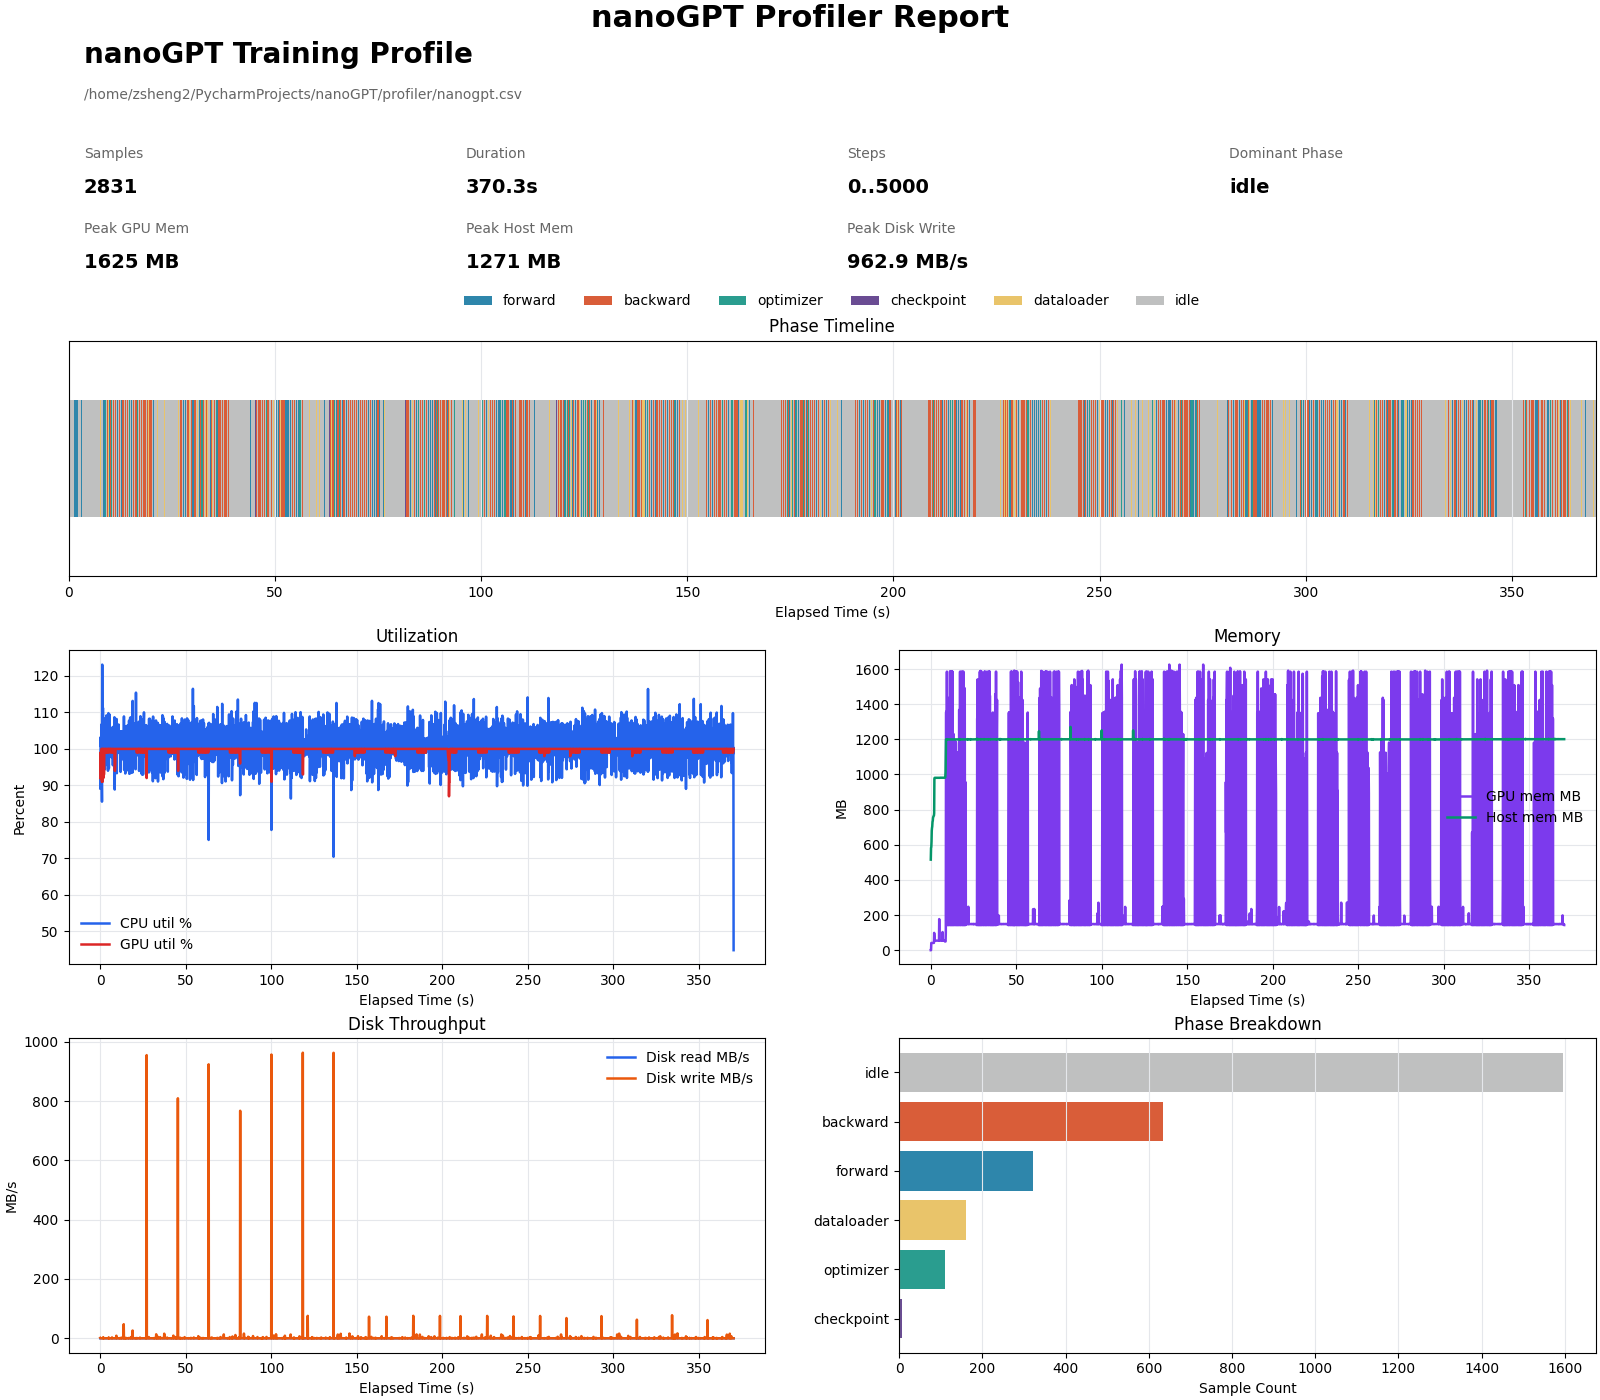

In [3]:
csv_path = resolve_csv_path()
rows = load_rows(csv_path)
fig = plot_report(rows, csv_path)
plt.show()

In [4]:
# Optional: save the current figure to disk.
# output_path = csv_path.with_suffix('.png')
# fig.savefig(output_path, dpi=180, bbox_inches='tight')
# output_path